# Scroll Regressions on SERPs

> **Task constraint note:** AdSERP participants must click a result — no abandonment or query reformulation. The 69% regression rate may be inflated: forced choice incentivizes thorough re-evaluation over abandonment. In real browsing, some regressions would be replaced by reformulation or tab-switching. The regression *patterns* (magnitude, timing, correlation with decision time) describe the mechanism; the *frequency* is an upper bound. See [findings caveats](docs/findings.md#caveats).

**Context:** Reading research has extensively studied fixation regressions (eyes moving backward to re-read). The equivalent at the page level — scrolling back up to re-examine previously viewed results — is common in SERP browsing but barely characterized in the literature.

### Key Measures

| Measure | Definition | Units | Interpretation |
|---------|-----------|-------|----------------|
| Scroll regression | A decrease in scroll offset (user scrolls back up) | event | 69% of trials contain at least one |
| Regression count | Number of scroll regressions per trial | count | Mean 2.8; correlates with decision time (r=0.66) |
| Regression magnitude | Distance scrolled backward | px | Mean ~1118px, equivalent to ~7 result slots |
| Regression rate | Fraction of a participant's trials containing regressions | % | Range 11-98% across participants (mean 67%, SD 21%) |


In [1]:
# Shared data loading — see data_loader.py for all utilities
from data_loader import *
setup_plotting()
import os
import csv
import math
import statistics
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt


In [2]:
trial_ids = get_trial_ids()

def extract_scroll_profile(trial_id):
    """Extract scroll timeline and detect regressions for one trial."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    scrolls = []
    click_t = None
    
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
            if r['event'] == 'click':
                click_t = t
    
    if not scrolls or click_t is None:
        return None
    
    # Segment into scroll gestures (gaps > 200ms)
    gestures = []
    gesture = [scrolls[0]]
    for i in range(1, len(scrolls)):
        if scrolls[i][0] - scrolls[i-1][0] > 200:
            gestures.append(gesture)
            gesture = [scrolls[i]]
        else:
            gesture.append(scrolls[i])
    gestures.append(gesture)
    
    # Classify each gesture as forward (down), regression (up), or mixed
    gesture_info = []
    for g in gestures:
        if len(g) < 2:
            continue
        start_y = g[0][1]
        end_y = g[-1][1]
        delta = end_y - start_y
        t_start = g[0][0]
        t_end = g[-1][0]
        ttc_start = (click_t - t_start) / 1000.0
        ttc_end = (click_t - t_end) / 1000.0
        
        gesture_info.append({
            'direction': 'down' if delta > 10 else ('up' if delta < -10 else 'neutral'),
            'delta_px': delta,
            'abs_delta': abs(delta),
            'start_y': start_y,
            'end_y': end_y,
            'ttc_start': ttc_start,
            'ttc_mid': (ttc_start + ttc_end) / 2,
            'duration_ms': t_end - t_start,
            'n_events': len(g),
        })
    
    # Trial-level stats
    regressions = [g for g in gesture_info if g['direction'] == 'up']
    forwards = [g for g in gesture_info if g['direction'] == 'down']
    max_scroll = max(s[1] for s in scrolls)
    trial_duration = (click_t - scrolls[0][0]) / 1000.0
    
    return {
        'trial': trial_id,
        'n_gestures': len(gesture_info),
        'n_regressions': len(regressions),
        'n_forwards': len(forwards),
        'max_scroll_px': max_scroll,
        'trial_duration_s': trial_duration,
        'has_regression': len(regressions) > 0,
        'total_regression_px': sum(g['abs_delta'] for g in regressions),
        'gestures': gesture_info,
        'regressions': regressions,
    }

# Process all trials
print("Extracting scroll profiles...")
profiles = []
for i, tid in enumerate(trial_ids):
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(trial_ids)}...")
    try:
        p = extract_scroll_profile(tid)
        if p:
            profiles.append(p)
    except:
        pass

has_scroll = [p for p in profiles if p['n_gestures'] > 0]
has_regression = [p for p in profiles if p['has_regression']]
no_regression = [p for p in profiles if not p['has_regression'] and p['n_gestures'] > 0]

print(f"\nTrials with scroll data: {len(has_scroll)}")
print(f"Trials with at least one regression: {len(has_regression)} ({len(has_regression)/len(has_scroll)*100:.1f}%)")
print(f"Trials with no regressions: {len(no_regression)} ({len(no_regression)/len(has_scroll)*100:.1f}%)")
print(f"\nAmong trials with regressions:")
reg_counts = [p['n_regressions'] for p in has_regression]
print(f"  Mean regressions per trial: {np.mean(reg_counts):.1f}")
print(f"  Median: {np.median(reg_counts):.0f}")
print(f"  Max: {max(reg_counts)}")
reg_px = [p['total_regression_px'] for p in has_regression]
print(f"  Mean total regression distance: {np.mean(reg_px):.0f}px")
print(f"  Median: {np.median(reg_px):.0f}px")

Extracting scroll profiles...


  500/2776...


  1000/2776...
  1500/2776...


  2000/2776...


  2500/2776...

Trials with scroll data: 2266
Trials with at least one regression: 1566 (69.1%)
Trials with no regressions: 700 (30.9%)

Among trials with regressions:
  Mean regressions per trial: 2.8
  Median: 2
  Max: 12
  Mean total regression distance: 1118px
  Median: 1020px


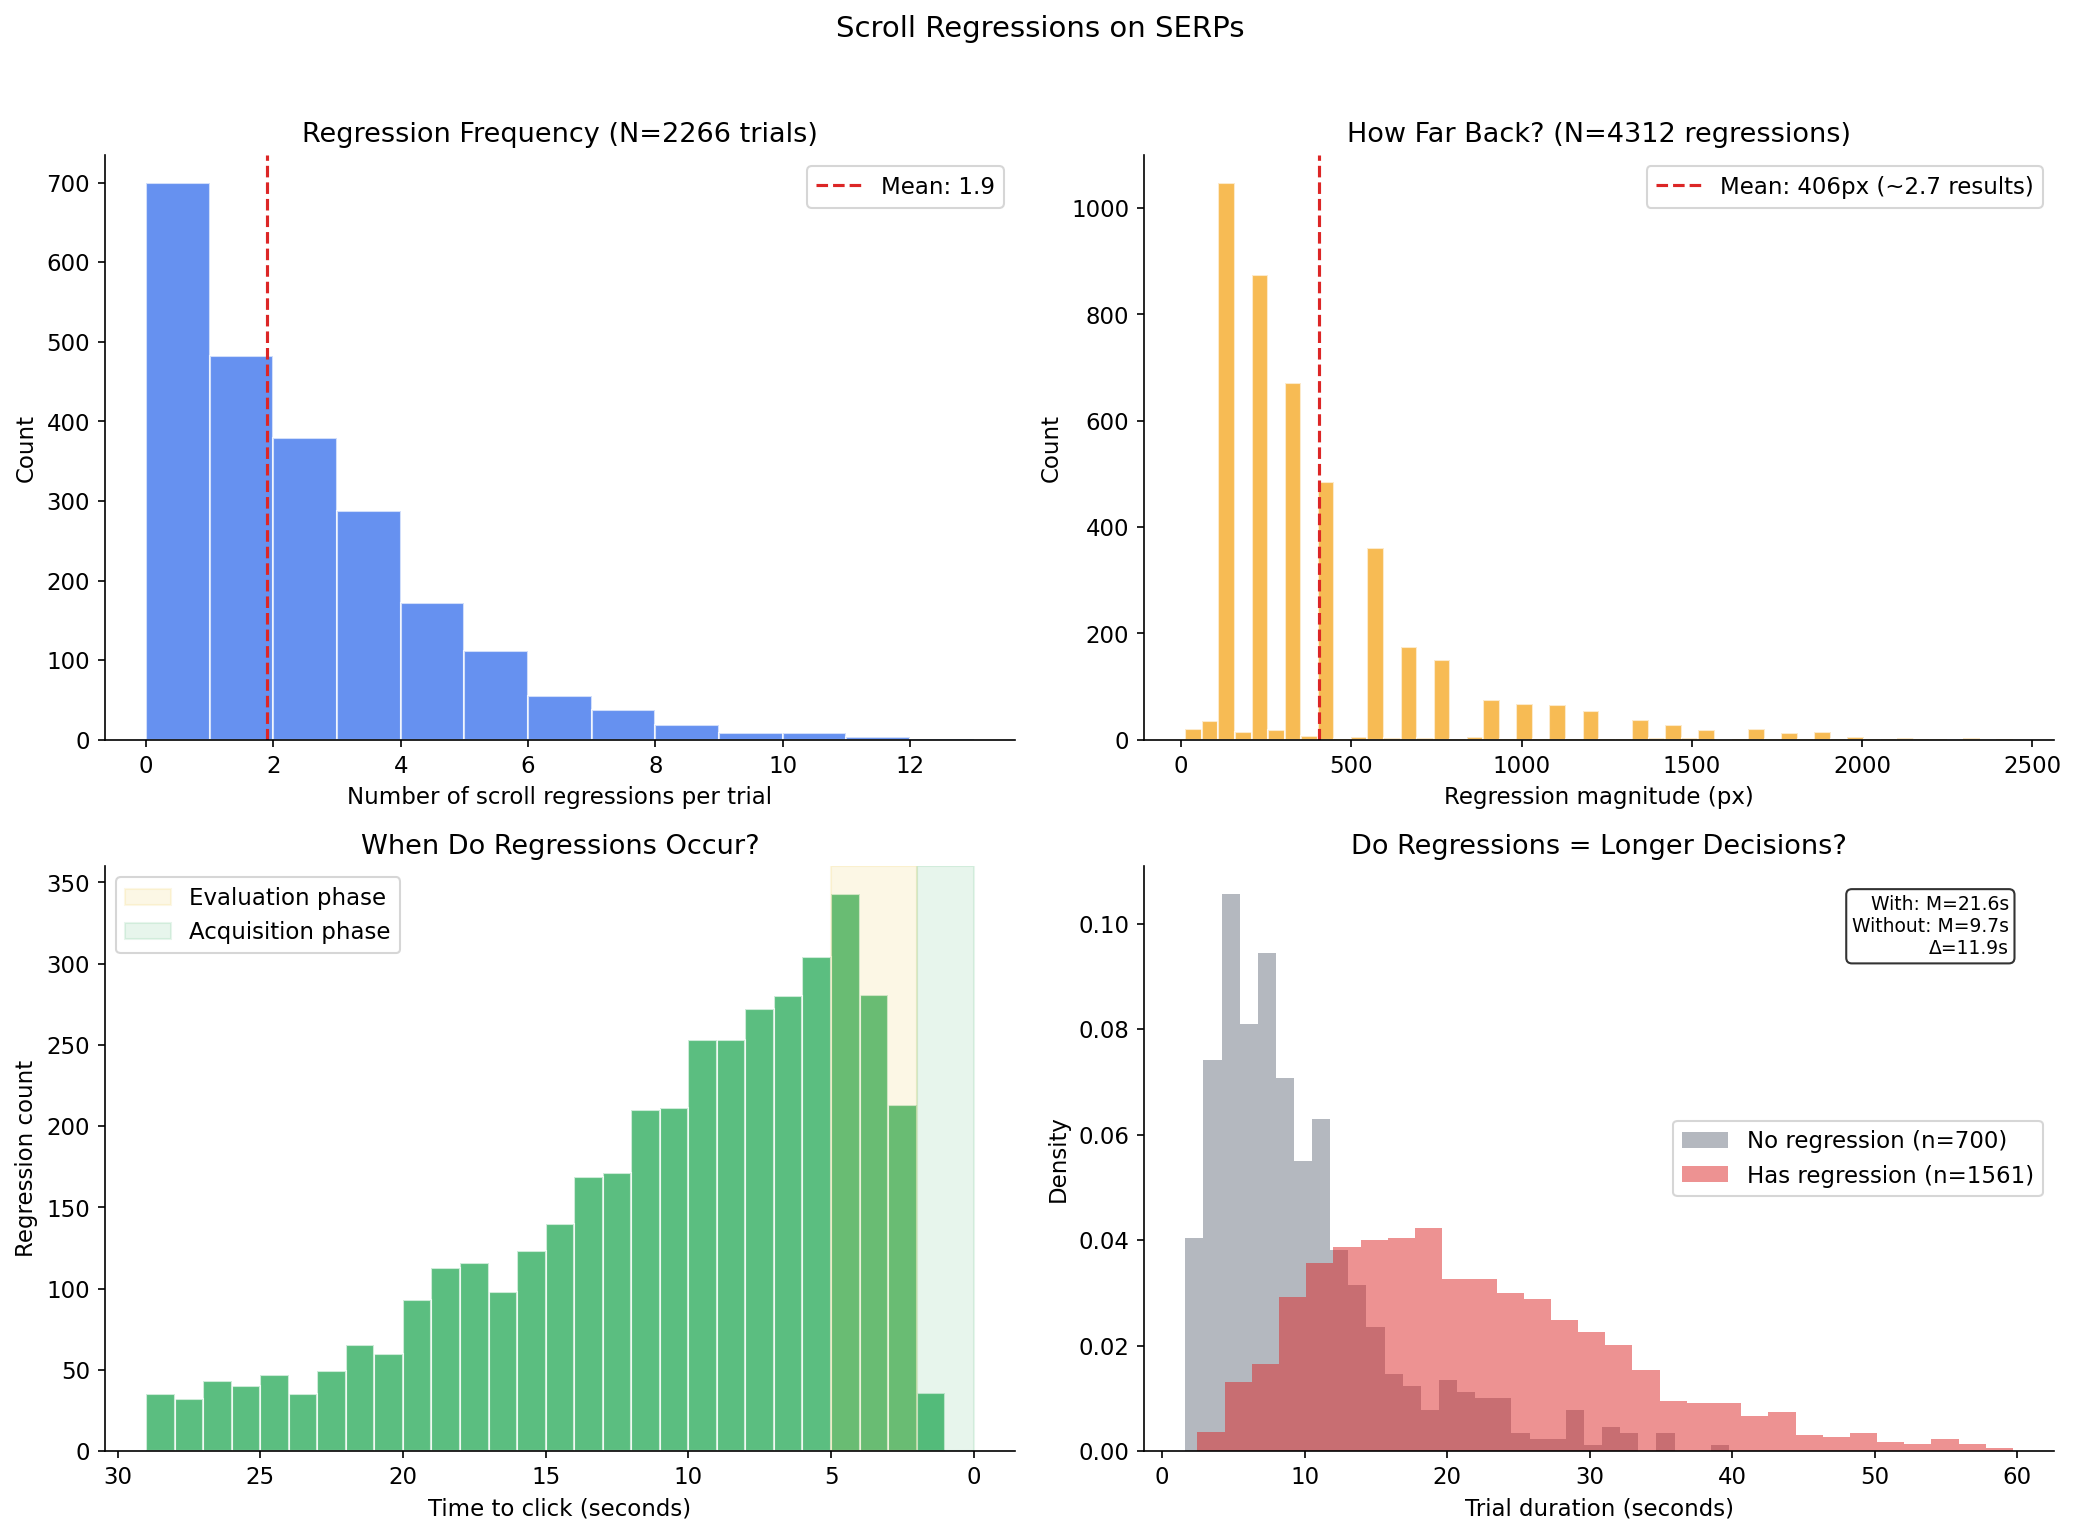

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Distribution of regression count per trial
ax = axes[0, 0]
all_reg_counts = [p['n_regressions'] for p in has_scroll]
ax.hist(all_reg_counts, bins=range(0, max(all_reg_counts)+2), color='#2563eb', alpha=0.7, edgecolor='white')
ax.set_xlabel('Number of scroll regressions per trial')
ax.set_ylabel('Count')
ax.set_title(f'Regression Frequency (N={len(has_scroll)} trials)')
ax.axvline(x=np.mean(all_reg_counts), color='#dc2626', linestyle='--', label=f'Mean: {np.mean(all_reg_counts):.1f}')
ax.legend()

# 2: Regression magnitude (how far back)
ax = axes[0, 1]
all_reg_deltas = [g['abs_delta'] for p in has_regression for g in p['regressions']]
ax.hist(all_reg_deltas, bins=50, color='#f59e0b', alpha=0.7, edgecolor='white')
ax.set_xlabel('Regression magnitude (px)')
ax.set_ylabel('Count')
ax.set_title(f'How Far Back? (N={len(all_reg_deltas)} regressions)')
ax.axvline(x=np.mean(all_reg_deltas), color='#dc2626', linestyle='--', 
           label=f'Mean: {np.mean(all_reg_deltas):.0f}px (~{np.mean(all_reg_deltas)/150:.1f} results)')
ax.legend()

# 3: When do regressions happen? (time-to-click)
ax = axes[1, 0]
reg_ttcs = [g['ttc_mid'] for p in has_regression for g in p['regressions']]
ax.hist(reg_ttcs, bins=np.arange(0, 30, 1), color='#16a34a', alpha=0.7, edgecolor='white')
ax.set_xlabel('Time to click (seconds)')
ax.set_ylabel('Regression count')
ax.set_title('When Do Regressions Occur?')
ax.axvspan(2, 5, alpha=0.1, color='#eab308', label='Evaluation phase')
ax.axvspan(0, 2, alpha=0.1, color='#16a34a', label='Acquisition phase')
ax.legend()
ax.invert_xaxis()

# 4: Trial duration — regression vs no regression
ax = axes[1, 1]
dur_with = [p['trial_duration_s'] for p in has_regression if p['trial_duration_s'] < 60]
dur_without = [p['trial_duration_s'] for p in no_regression if p['trial_duration_s'] < 60]
ax.hist(dur_without, bins=30, alpha=0.5, color='#6b7280', label=f'No regression (n={len(dur_without)})', density=True)
ax.hist(dur_with, bins=30, alpha=0.5, color='#dc2626', label=f'Has regression (n={len(dur_with)})', density=True)
ax.set_xlabel('Trial duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Do Regressions = Longer Decisions?')
ax.legend()
ax.text(0.95, 0.85, f'With: M={np.mean(dur_with):.1f}s\nWithout: M={np.mean(dur_without):.1f}s\nΔ={np.mean(dur_with)-np.mean(dur_without):.1f}s',
        transform=ax.transAxes, ha='right', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Scroll Regressions on SERPs', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_reg1_overview.png', dpi=200, bbox_inches='tight')
plt.show()

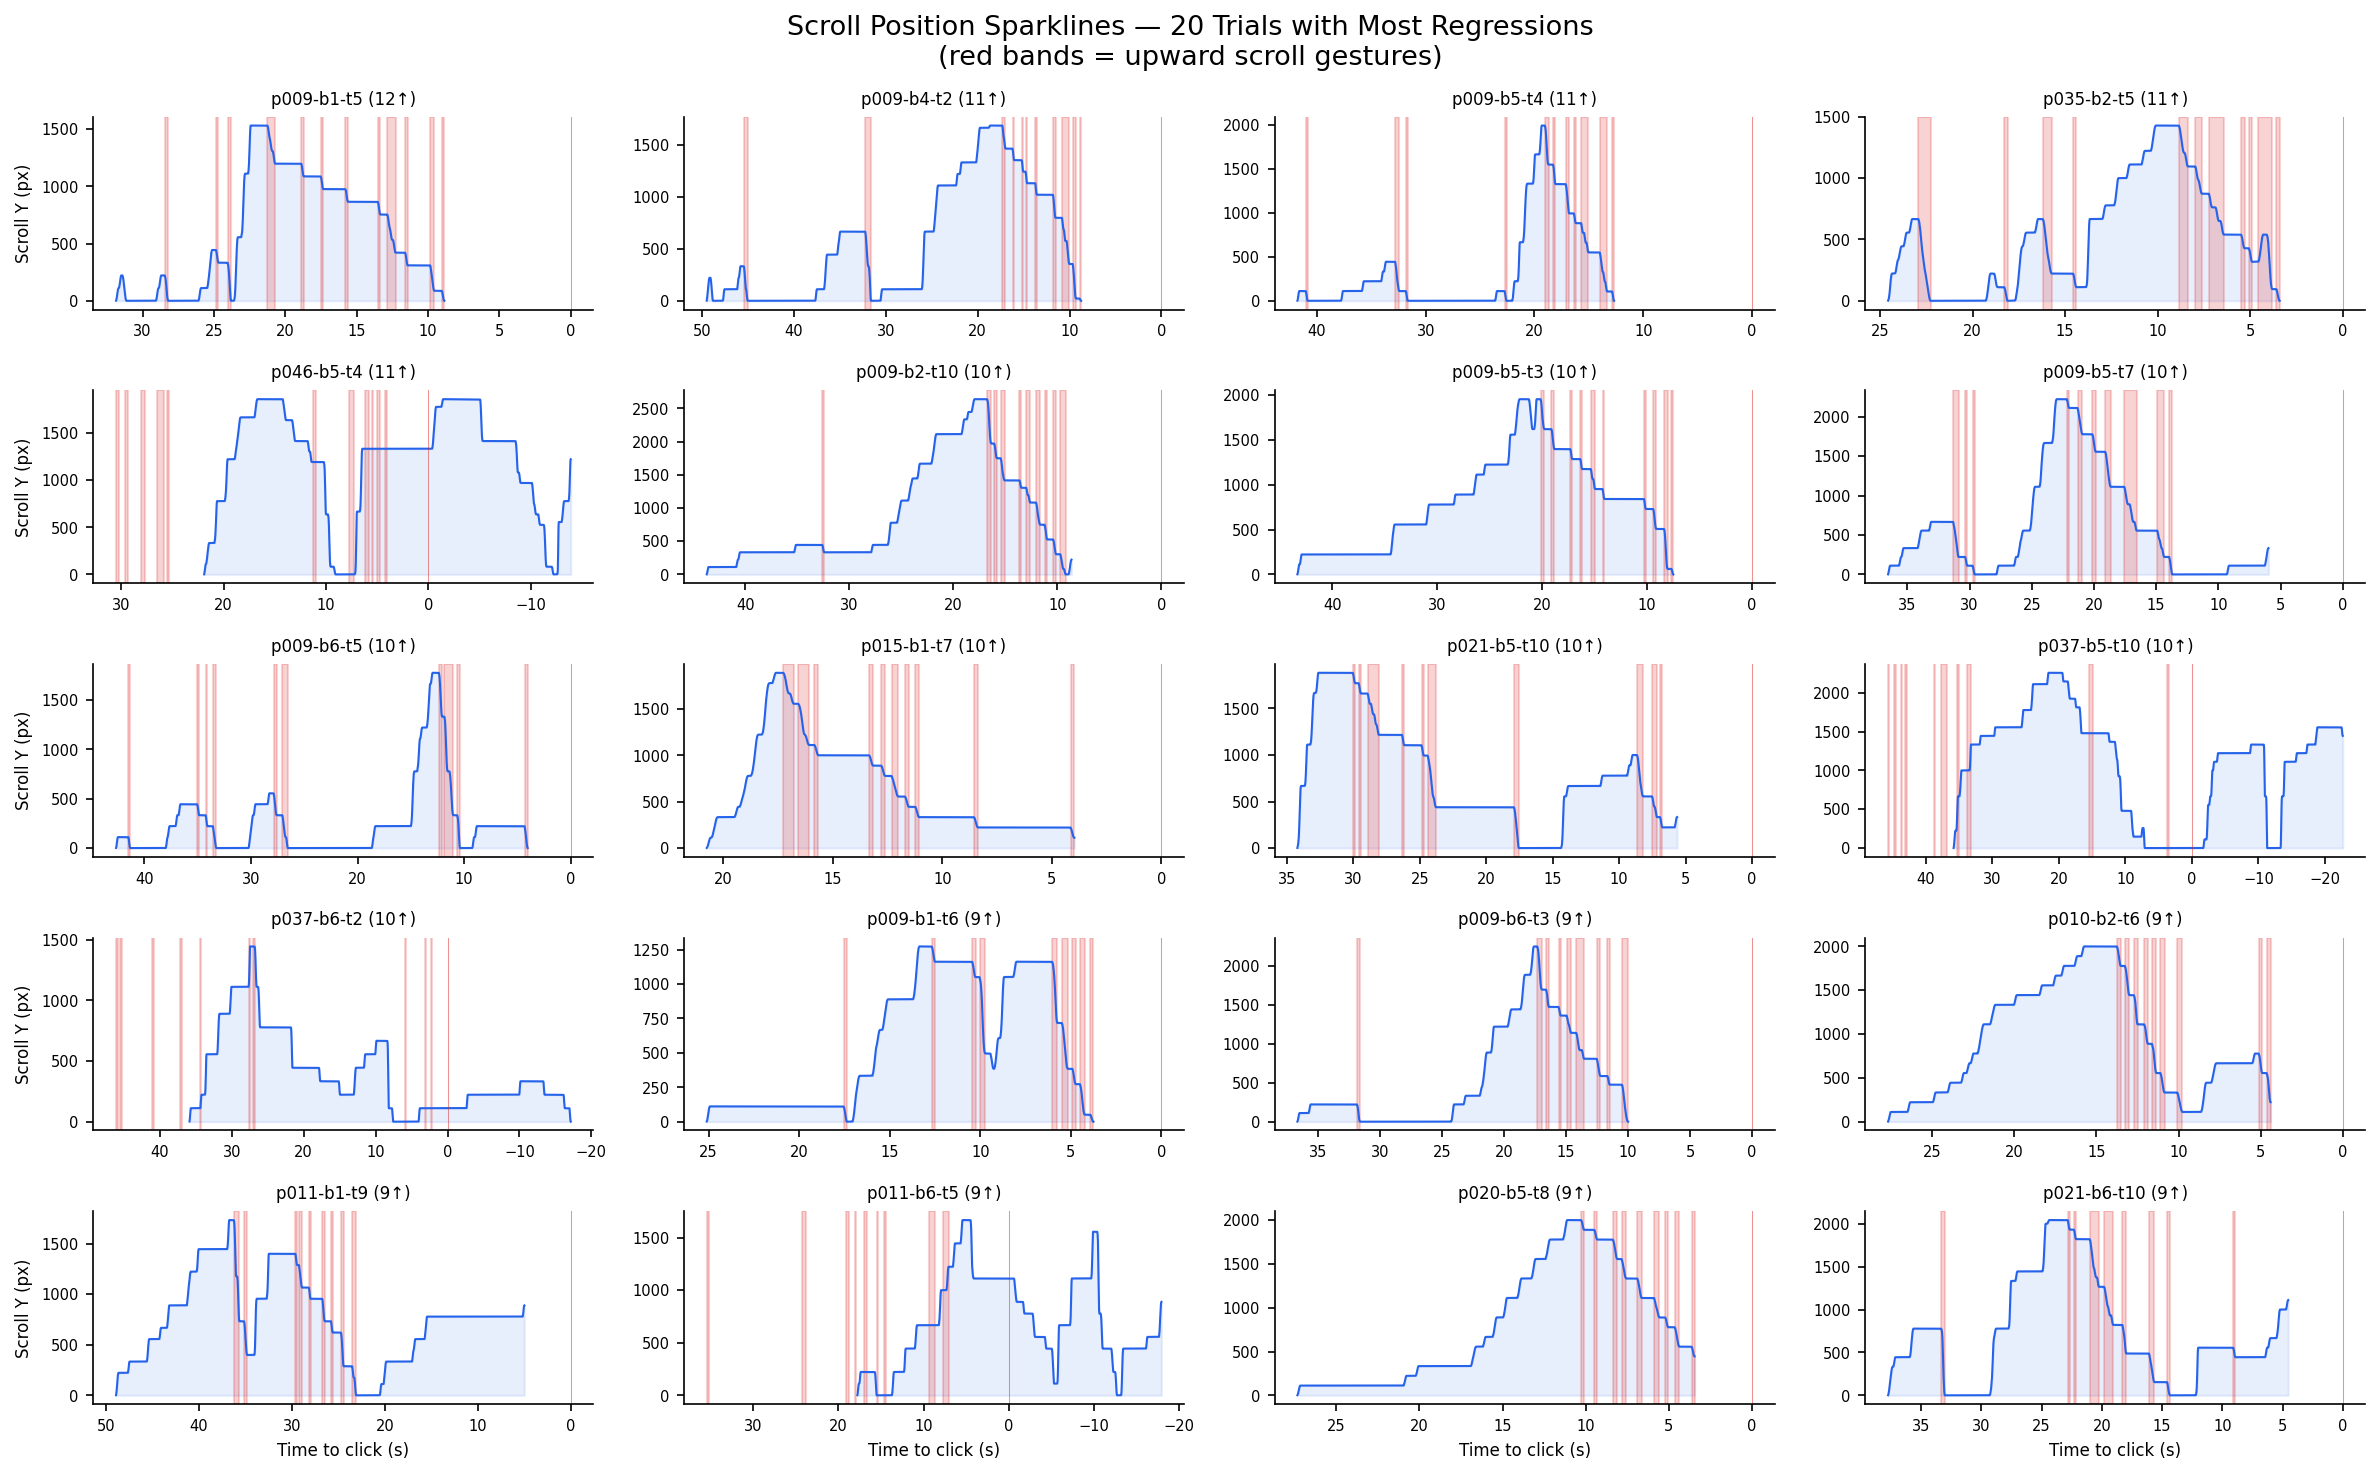

In [4]:
# Scroll sparklines: show 20 sample trials as scroll-position-over-time
fig, axes = plt.subplots(5, 4, figsize=(16, 10), sharex=False, sharey=False)
axes_flat = axes.flatten()

# Pick 20 trials with regressions, sorted by regression count
sample = sorted(has_regression, key=lambda p: -p['n_regressions'])[:20]

for idx, profile in enumerate(sample):
    ax = axes_flat[idx]
    tid = profile['trial']
    
    # Reload raw scroll data for this trial
    # Delegate CSV parsing to data_loader
    _, scrolls, clicks_raw = load_mouse_events(tid)
    click_t = clicks_raw[0][0] if clicks_raw else None
    
    if not scrolls or not click_t:
        continue
    
    # Plot scroll position over time-to-click
    xs = [(click_t - s[0]) / 1000.0 for s in scrolls]
    ys = [s[1] for s in scrolls]
    
    ax.plot(xs, ys, color='#2563eb', linewidth=1)
    ax.fill_between(xs, 0, ys, alpha=0.1, color='#2563eb')
    ax.axvline(x=0, color='#dc2626', linewidth=0.5, alpha=0.5)
    
    # Mark regressions
    for g in profile['regressions']:
        ax.axvspan(g['ttc_start'], g['ttc_start'] - g['duration_ms']/1000, 
                   alpha=0.2, color='#dc2626')
    
    ax.set_title(f'{tid} ({profile["n_regressions"]}↑)', fontsize=8)
    ax.invert_xaxis()
    ax.tick_params(labelsize=7)
    if idx >= 16:
        ax.set_xlabel('Time to click (s)', fontsize=8)
    if idx % 4 == 0:
        ax.set_ylabel('Scroll Y (px)', fontsize=8)

plt.suptitle('Scroll Position Sparklines — 20 Trials with Most Regressions\n(red bands = upward scroll gestures)', fontsize=13)
plt.tight_layout()
plt.savefig('plot_reg2_sparklines.png', dpi=200, bbox_inches='tight')
plt.show()

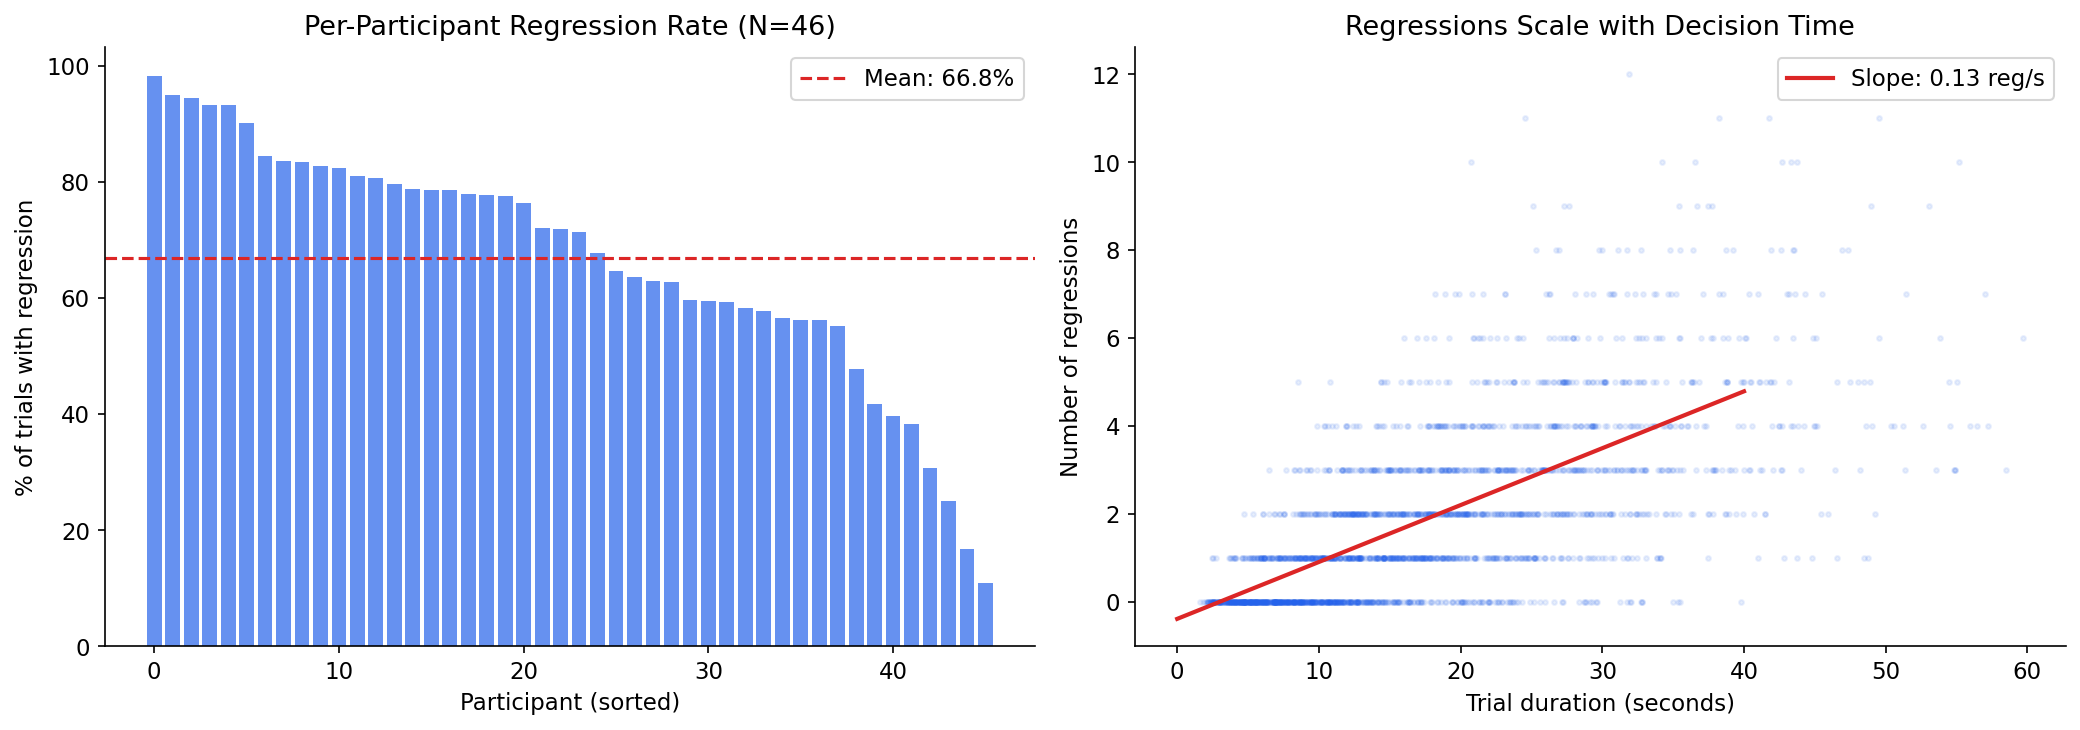

Per-participant regression rate: 66.8% ± 20.6%
Range: 11% - 98%
Regression-duration correlation: r=0.660


In [5]:
# Per-participant regression rate
by_participant = defaultdict(lambda: {'total': 0, 'with_reg': 0, 'reg_counts': []})
for p in has_scroll:
    pid = p['trial'].split('-')[0]
    by_participant[pid]['total'] += 1
    by_participant[pid]['reg_counts'].append(p['n_regressions'])
    if p['has_regression']:
        by_participant[pid]['with_reg'] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Regression rate per participant
pids = sorted(by_participant.keys())
rates = [by_participant[pid]['with_reg'] / by_participant[pid]['total'] * 100 for pid in pids]
means = [np.mean(by_participant[pid]['reg_counts']) for pid in pids]

ax1.bar(range(len(pids)), sorted(rates, reverse=True), color='#2563eb', alpha=0.7)
ax1.set_xlabel('Participant (sorted)')
ax1.set_ylabel('% of trials with regression')
ax1.set_title(f'Per-Participant Regression Rate (N={len(pids)})')
ax1.axhline(y=np.mean(rates), color='#dc2626', linestyle='--', label=f'Mean: {np.mean(rates):.1f}%')
ax1.legend()

# Regression count vs trial duration
all_durations = [p['trial_duration_s'] for p in has_scroll if p['trial_duration_s'] < 60]
all_regs = [p['n_regressions'] for p in has_scroll if p['trial_duration_s'] < 60]
ax2.scatter(all_durations, all_regs, alpha=0.1, s=5, color='#2563eb')
ax2.set_xlabel('Trial duration (seconds)')
ax2.set_ylabel('Number of regressions')
ax2.set_title('Regressions Scale with Decision Time')

# Fit line
from numpy.polynomial import polynomial as P
mask = np.array(all_durations) < 40
coef = np.polyfit(np.array(all_durations)[mask], np.array(all_regs)[mask], 1)
x_fit = np.linspace(0, 40, 100)
ax2.plot(x_fit, np.polyval(coef, x_fit), color='#dc2626', linewidth=2, 
         label=f'Slope: {coef[0]:.2f} reg/s')
ax2.legend()

plt.tight_layout()
plt.savefig('plot_reg3_participants.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Per-participant regression rate: {np.mean(rates):.1f}% ± {np.std(rates):.1f}%")
print(f"Range: {min(rates):.0f}% - {max(rates):.0f}%")
print(f"Regression-duration correlation: r={np.corrcoef(all_durations, all_regs)[0,1]:.3f}")